# Tranfer learning for 3 classification Chapter 10 Workshop 4

## Load module

In [52]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

## Declare variable

In [53]:
target_size = (128, 128)

train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\train_set'
val_dir = r"D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\val_set"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=32,
    class_mode='sparse',
)

val_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

val_set = val_datagen.flow_from_directory(val_dir,
                                                  target_size=target_size,
                                                  batch_size=32,
                                                  class_mode='sparse')

Found 150 images belonging to 3 classes.
Found 41 images belonging to 3 classes.


## Check dataset

In [54]:
print(train_set.class_indices)

ids, counts = np.unique(train_set.classes, return_counts=True)
print(ids)
print(counts)

{'cat': 0, 'dog': 1, 'elephant': 2}
[0 1 2]
[50 50 50]


In [55]:
labels = train_set.class_indices
labels = {v: k for k, v in labels.items()}
print(labels)
for i in ids:
    print(labels[i], counts[i])

{0: 'cat', 1: 'dog', 2: 'elephant'}
cat 50
dog 50
elephant 50


In [56]:
_, train_count = np.unique(train_set.classes, return_counts=True)
_, val_count = np.unique(val_set.classes, return_counts=True)

# Val/Train ratio not less than 0.1 (10%)
print(f"Ratio Val/Train set: {val_count/train_count*100}")

Ratio Val/Train set: [32. 30. 20.]


## Create ResNet50 model

In [57]:
in_shape = (target_size[0], target_size[1], 3)

### load resnet50 base model

In [58]:
base_model = ResNet50(weights='imagenet', 
                      include_top=False, 
                      input_shape=(128, 128, 3))

base_model.summary()


Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']      

### add classification layer

In [59]:
tranfer_resnet50_model = Sequential()

tranfer_resnet50_model.add(base_model)
tranfer_resnet50_model.add(Flatten())
tranfer_resnet50_model.add(Dense(256, activation='relu'))
tranfer_resnet50_model.add(Dropout(0.4))
tranfer_resnet50_model.add(Dense(128, activation='relu'))
tranfer_resnet50_model.add(Dropout(0.4))
tranfer_resnet50_model.add(Dense(3, activation='softmax'))



### freeze base layer

In [60]:
base_model.trainable = False
tranfer_resnet50_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 flatten_2 (Flatten)         (None, 32768)             0         
                                                                 
 dense_6 (Dense)             (None, 256)               8388864   
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 128)               32896     
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_8 (Dense)             (None, 3)                

## Compile model

In [61]:
from tensorflow.keras.optimizers import Adam

adam = Adam(learning_rate=1e-5)

tranfer_resnet50_model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

## Train model

In [62]:
es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)
mc = ModelCheckpoint('3_classes_tranfer_resnet50_model.h5',
                       monitor='val_loss',
                       save_best_only=True,
                       verbose=1)


history = tranfer_resnet50_model.fit(train_set,
                                     steps_per_epoch=len(train_set),
                                     epochs=20,
                                     validation_data=val_set,
                                     validation_steps=len(val_set),
                                     verbose=1,
                                     callbacks=[es, mc])   

Epoch 1/20
5/5 [==============================] - ETA: 0s - loss: 14.9803 - accuracy: 0.4467
Epoch 1: val_loss improved from inf to 8.68060, saving model to 3_classes_tranfer_resnet50_model.h5
5/5 [==============================] - 4s 652ms/step - loss: 14.9803 - accuracy: 0.4467 - val_loss: 8.6806 - val_accuracy: 0.6098
Epoch 2/20
5/5 [==============================] - ETA: 0s - loss: 8.1339 - accuracy: 0.7333
Epoch 2: val_loss improved from 8.68060 to 6.34498, saving model to 3_classes_tranfer_resnet50_model.h5
5/5 [==============================] - 2s 336ms/step - loss: 8.1339 - accuracy: 0.7333 - val_loss: 6.3450 - val_accuracy: 0.7317
Epoch 3/20
5/5 [==============================] - ETA: 0s - loss: 3.8935 - accuracy: 0.8267
Epoch 3: val_loss improved from 6.34498 to 2.36995, saving model to 3_classes_tranfer_resnet50_model.h5
5/5 [==============================] - 1s 301ms/step - loss: 3.8935 - accuracy: 0.8267 - val_loss: 2.3699 - val_accuracy: 0.8293
Epoch 4/20
5/5 [===========

## Loss and Accuracy Curve

[14.980340003967285, 8.133940696716309, 3.893481492996216, 3.5293216705322266, 3.639317274093628, 3.436450719833374, 1.369874358177185, 0.8090181946754456, 1.682847499847412, 0.8286945819854736]


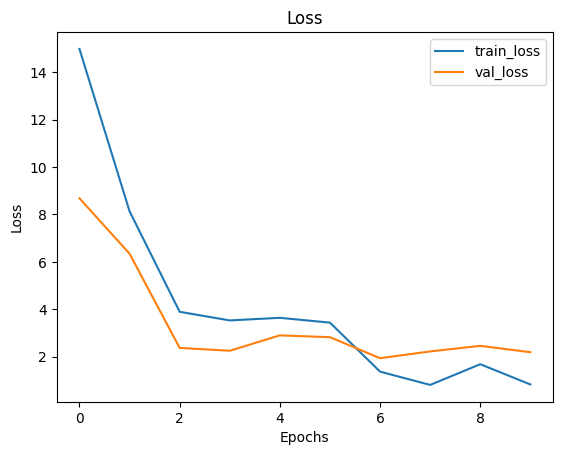

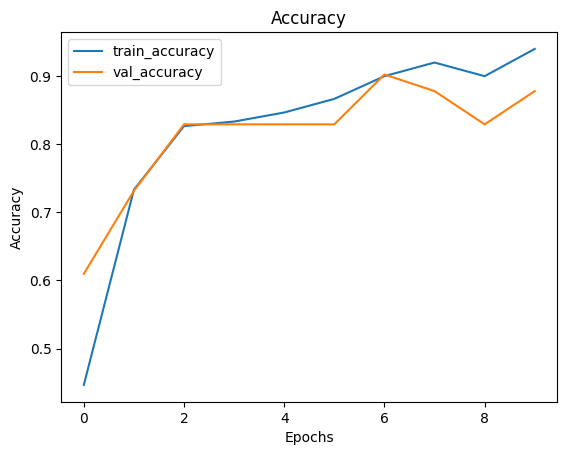

In [66]:

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()


plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

## Evaluate model

In [67]:
score = tranfer_resnet50_model.evaluate(val_set, verbose=1)
print('Test loss:', round(score[0],3))
print('Test accuracy:', round(score[1],3))

2/2 [==============================] - 0s 8ms/step - loss: 1.5897 - accuracy: 0.9024
Test loss: 1.59
Test accuracy: 0.902


## Prediction

### Declare predict function

In [89]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(model, image_path):
    img = load_img(image_path, target_size=(128, 128))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    pred = model.predict(img)
    pred_class = labels[np.argmax(pred, axis=1)[0]]
    print(f"Predicted class: {pred_class}", pred[0].round(5))

In [ ]:
image_path = r"D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\test_set\cat3.jpg"
predict_image(tranfer_resnet50_model, image_path)

1/1 [==============================] - 0s 9ms/step
Predicted class: cat [1. 0. 0.]


In [92]:
model_path = r"D:\Project\Learning\TensorFlow_Files\model\3_classes_tranfer_resnet50_model.h5"
tranfer_resnet50_model.save(model_path)